This notebook walks through an initiation of the analysis object and reads in the detections and templates from previous studies.

In [13]:
import numpy as np
import obspy
import lfeanalysis
import read_catalogues
import matplotlib.pyplot as plt
from importlib import reload
reload(lfeanalysis)

<module 'lfeanalysis' from '/home/petoskey_data/Dropbox/SMALLSYNC/PYFILES/LFEFocMech/lfeanalysis.py'>

### 1. Initialize an analysis object and specify the data directory

The codes will need to access and save data.  You'll need to pick and create a directory for your files.  

In [14]:
# we first note where all the data are stored
# modify this as needed
import os
data_directory=os.path.join(os.environ['DATA'],'LFEAnalysis')
print('All of the data will be retrieved and stored in {:s}'.format(data_directory))

# now we can create an analysis object
# we choose a particular family: here #74
lf=lfeanalysis.lfanalyse(fnum=74,data_directory=data_directory)

All of the data will be retrieved and stored in /home/earthquakes2/homes/Jess/DATA/LFEAnalysis


### 2. Read in the list of detections and any existing templates

In [24]:
# read the detection times and any existing templates
reload(read_catalogues)
reload(lfeanalysis)
lf=lfeanalysis.lfanalyse(fnum=74,data_directory=data_directory)
lf.read_detection_info()

In [25]:
# the most important thing here is the times of detected LFEs that
# belong to this family
lf.tms

array([UTCDateTime(2003, 2, 26, 5, 54, 40, 675000),
       UTCDateTime(2003, 2, 26, 9, 36, 13, 675000),
       UTCDateTime(2003, 2, 26, 10, 13, 9, 750000), ...,
       UTCDateTime(2013, 10, 5, 16, 25, 17, 600000),
       UTCDateTime(2013, 10, 5, 16, 28, 11, 325000),
       UTCDateTime(2013, 10, 10, 18, 54, 14, 875000)], dtype=object)

In [26]:
# the LFE magnitudes may also be available
lf.mags

array([1.734, 1.697, 1.717, ..., 1.753, 1.583, 1.996])

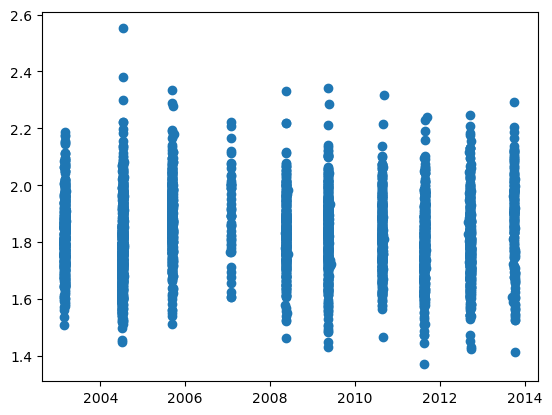

In [27]:
# it might be interesting to look at these detections
plt.plot_date(lf.tms,lf.mags)

(12600.0, 12630.0)

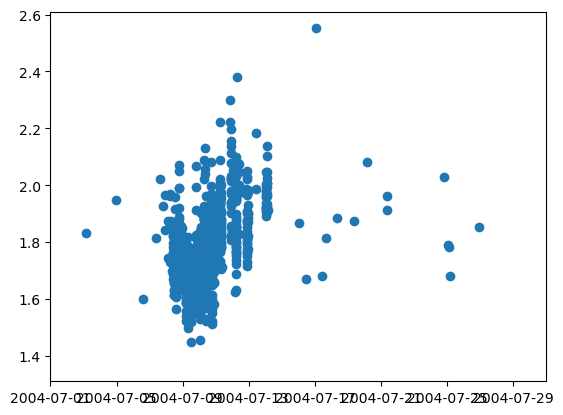

In [28]:
# it might be interesting to look at these detections
plt.plot_date(lf.tms,lf.mags)
t1=obspy.UTCDateTime(2004,7,1)
plt.xlim([t1,t1+86400*30])

In [29]:
# and we'll note the location of this family
print('LFE location: ',lf.floc)

LFE location:  [-123.7003   48.1192   29.09  ]


In [30]:
# and we may also have existing stacks of the LFEs from previous work
lf.sttemp

177 Trace(s) in Stream:

.B012..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:59.975000Z | 40.0 Hz, 2400 samples
...
(175 other traces)
...
.B004..Z | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:59.975000Z | 40.0 Hz, 2400 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]

### 3. Pick the stations to use for analysis

In [31]:
# if a previous study has already made stacks of LFEs: templates,
# let's identify the arrival times and signal to noise power ratios in those stacks
lf.pick_templates(minsnr=5)

In [32]:
# the signal to noise ratio estimated are saved in a dictionary
lf.temp_snrs

{'A04A': 5.835845450654718,
 'A04D': 5.5235563782208725,
 'B001': 2.096527009389917,
 'B003': 8.38780346336646,
 'B004': 6.066802531267702,
 'B007': 13.655727317038611,
 'B011': 47.56714694878726,
 'B012': 2.0572412700406018,
 'B04A': 1.9286504674680123,
 'B926': 121.58119985218235,
 'B927': 5.334588485828302,
 'B928': 6.555337276695893,
 'BIB': nan,
 'BMSB': 2.091556613847129,
 'BPCB': 31.334153214496176,
 'CPLB': 1.7905077126598437,
 'ENGB': 1.9083591841793002,
 'GHNB': 4.784930599183665,
 'GLBC': 6.3740600942949595,
 'GOBB': nan,
 'GOWB': 82.24148895823787,
 'JRBC': 15.961163899191089,
 'KELB': 15.898569889936066,
 'KHVB': 28.84447516395185,
 'KLNB': 33.597010095794055,
 'LCBC': 2.170282560042523,
 'LOP3': 1.230037255577648,
 'LRIV': 7.283641045533715,
 'LZB': 76.17420287635889,
 'MGB': 36.175717489469065,
 'MGCB': 57.41064586535943,
 'NLLB': 50.39382428597287,
 'OPC': 1.807880357123905,
 'OZB': 4.998336824484352,
 'PFB': 38.38005184342541,
 'PGC': 55.19015960828753,
 'PHYB': 25.928

In [33]:
# and the stations that have signal to noise ratios bigger 
# than minsnr input above are listed 
lf.stns

array(['A04A', 'A04D', 'B003', 'B004', 'B007', 'B011', 'B926', 'B927',
       'B928', 'BPCB', 'GLBC', 'GOWB', 'JRBC', 'KELB', 'KHVB', 'KLNB',
       'LRIV', 'LZB', 'MGB', 'MGCB', 'NLLB', 'PFB', 'PGC', 'PHYB', 'SHB',
       'SHDB', 'SHVB', 'SILB', 'SNB', 'SOK1', 'SOK2', 'SOK4', 'SOK5',
       'SOK6', 'SOKB', 'SSIB', 'TFRB', 'TSJB', 'TWBB', 'TWGB', 'TWKB',
       'VGZ', 'YOUB'], dtype='<U4')

If you plan to download data, the stations to be used are saved in lf.stns.  So if you don't have templates from a previous study, you can just create a list of stations and save it as lf.stns.

In [34]:
# for this example, though, we do have a template, and the function 
# pick_template picks the time window that is largest relative to the time window before it
# the start time of the data window is given by the 't0' parameter in the seismogram

# let's pick a trace
tr=lf.sttemp[0]
print('A trace:\n',tr)

# and look at its value of t0
print('\nAll the trace\'s statistics:\n',tr.stats)
print('\nThe window\'s start time:\n',tr.stats.t0)

A trace:
 .B012..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:59.975000Z | 40.0 Hz, 2400 samples

All the trace's statistics:
          network: 
         station: B012
        location: 
         channel: E
       starttime: 1970-01-01T00:00:00.000000Z
         endtime: 1970-01-01T00:00:59.975000Z
   sampling_rate: 40.0
           delta: 0.025
            npts: 2400
           calib: 1.0
             snr: 2.0572412700406018
              t0: 54.45
              t1: 59.45

The window's start time:
 54.45
